
# Energy Consumption in Buildings Analysis System
## Comprehensive Data Preprocessing & Advanced Data Visualization Pipeline

This notebook includes an end-to-end implementation featuring extensive **Data Preprocessing** and rich **Exploratory Data Visualizations**.


### 1. Import Libraries and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)


### 2. Step 1: Load Raw Datasets

In [3]:

data_dir = '../data'
building_metadata = pd.read_csv(os.path.join(data_dir, 'building_metadata.csv'))
weather_train = pd.read_csv(os.path.join(data_dir, 'weather_train.csv'))
train = pd.read_csv(os.path.join(data_dir, 'train.csv'), nrows=1000000)

print(f"Building Metadata: {building_metadata.shape}")
print(f"Weather Train: {weather_train.shape}")
print(f"Train (Sampled): {train.shape}")
building_metadata.head()


Building Metadata: (1449, 6)
Weather Train: (139773, 9)
Train (Sampled): (1000000, 4)


,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


### 3. Step 2: Comprehensive Data Quality & Missing Value Inspection

In [4]:

print("--- Missing Values in Building Metadata (%) ---")
print((building_metadata.isnull().sum() / len(building_metadata) * 100).round(2))

print("\n--- Missing Values in Weather Data (%) ---")
print((weather_train.isnull().sum() / len(weather_train) * 100).round(2))

print("\n--- Missing Values in Train Data ---")
print(train.isnull().sum())


--- Missing Values in Building Metadata (%) ---
site_id         0.00
building_id     0.00
primary_use     0.00
square_feet     0.00
year_built     53.42
floor_count    75.50
dtype: float64

--- Missing Values in Weather Data (%) ---
site_id                0.00
timestamp              0.00
air_temperature        0.04
cloud_coverage        49.49
dew_temperature        0.08
precip_depth_1_hr     35.98
sea_level_pressure     7.60
wind_direction         4.48
wind_speed             0.22
dtype: float64

--- Missing Values in Train Data ---
building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64


### 4. Step 3: Align Time Bases & Temporal Aggregation

In [5]:

train['timestamp'] = pd.to_datetime(train['timestamp'])
weather_train['timestamp'] = pd.to_datetime(weather_train['timestamp'])

train['date'] = train['timestamp'].dt.date
train['hour'] = train['timestamp'].dt.hour

weather_train['date'] = weather_train['timestamp'].dt.date

# Daily aggregation for Train data with statistical summaries
train_daily = train.groupby(['building_id', 'meter', 'date']).agg({
    'meter_reading': ['sum', 'mean', 'std', 'min', 'max'],
    'hour': 'count'
}).reset_index()
train_daily.columns = ['building_id', 'meter', 'date', 'total_energy', 'avg_energy',
                       'std_energy', 'min_energy', 'max_energy', 'readings_count']

# Daily aggregation for Weather features
weather_daily = weather_train.groupby(['site_id', 'date']).agg({
    'air_temperature': ['mean', 'min', 'max', 'std'],
    'cloud_coverage': 'mean',
    'dew_temperature': 'mean',
    'precip_depth_1_hr': 'sum',
    'sea_level_pressure': 'mean',
    'wind_direction': 'mean',
    'wind_speed': ['mean', 'max']
}).reset_index()
weather_daily.columns = ['site_id', 'date', 'temp_mean', 'temp_min', 'temp_max', 'temp_std',
                         'cloud_coverage', 'dew_temp', 'precip_total', 'pressure',
                         'wind_direction', 'wind_speed_mean', 'wind_speed_max']

print(f"Daily aggregated train shape: {train_daily.shape}")


Daily aggregated train shape: (43735, 9)


### 5. Step 4: Multi-Dataset Merging

In [6]:

merged = train_daily.merge(building_metadata, on='building_id', how='left')
merged = merged.merge(weather_daily, on=['site_id', 'date'], how='left')
print(f"Merged Dataset Shape: {merged.shape}")
merged.head()


Merged Dataset Shape: (43735, 25)


,building_id,meter,date,total_energy,avg_energy,std_energy,min_energy,max_energy,readings_count,site_id,primary_use,square_feet,year_built,floor_count,temp_mean,temp_min,temp_max,temp_std,cloud_coverage,dew_temp,precip_total,pressure,wind_direction,wind_speed_mean,wind_speed_max
0,0,0,2016-01-01,0.0,0.0,0.0,0.0,0.0,24,0,Education,7432,2008.0,NaN,23.337500,18.9,28.3,3.156196,4.285714,20.020833,-4.0,1018.926087,122.916667,1.854167,5.1
1,0,0,2016-01-02,0.0,0.0,0.0,0.0,0.0,24,0,Education,7432,2008.0,NaN,19.537500,15.0,24.4,2.492565,5.666667,15.325000,-2.0,1018.960870,167.500000,3.925000,6.2
2,0,0,2016-01-03,0.0,0.0,0.0,0.0,0.0,24,0,Education,7432,2008.0,NaN,14.829167,12.8,17.8,1.283162,8.000000,12.479167,12.0,1017.241667,276.666667,5.000000,8.2
3,0,0,2016-01-04,0.0,0.0,0.0,0.0,0.0,24,0,Education,7432,2008.0,NaN,12.666667,8.9,17.8,3.175130,2.428571,4.429167,16.0,1015.621739,318.333333,4.283333,6.2
4,0,0,2016-01-05,0.0,0.0,0.0,0.0,0.0,24,0,Education,7432,2008.0,NaN,14.058333,10.0,20.0,3.591889,1.333333,7.066667,0.0,1022.370833,142.083333,6.258333,8.8


### 6. Step 5: Advanced Missing Value Imputation Strategy

In [7]:

# Metadata imputation
merged['year_built'] = merged['year_built'].fillna(merged['year_built'].median())
merged['floor_count'] = merged['floor_count'].fillna(1)

# Group-based weather imputation (forward and backward fills per site_id)
weather_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_std', 'cloud_coverage',
                'dew_temp', 'precip_total', 'pressure', 'wind_direction',
                'wind_speed_mean', 'wind_speed_max']

for col in weather_cols:
    if col in merged.columns:
        merged[col] = merged.groupby('site_id')[col].transform(lambda x: x.ffill().bfill())
        merged[col] = merged[col].fillna(merged[col].median())

# Fill remaining numeric features
numeric_cols = merged.select_dtypes(include=[np.number]).columns
merged[numeric_cols] = merged[numeric_cols].fillna(merged[numeric_cols].median())

print("Missing values after cleaning:", merged.isnull().sum().sum())


Missing values after cleaning: 0


### 7. Step 6: Outlier Detection and Winsorization (IQR Capping)

In [8]:

Q1 = merged['total_energy'].quantile(0.25)
Q3 = merged['total_energy'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((merged['total_energy'] < lower_bound) | (merged['total_energy'] > upper_bound)).sum()
print(f"Outliers detected: {outliers_count} ({outliers_count/len(merged)*100:.2f}%)")

# Cap outliers to prevent distortion in models
merged['total_energy'] = merged['total_energy'].clip(lower_bound, upper_bound)


Outliers detected: 5880 (13.44%)


### 8. Step 7: Domain-Specific Feature Engineering

In [9]:

current_year = 2024

# 1. Building Features
merged['building_age'] = current_year - merged['year_built']
merged['energy_per_sqft'] = merged['total_energy'] / merged['square_feet'].replace(0, np.nan)
merged['avg_energy_per_sqft'] = merged['avg_energy'] / merged['square_feet'].replace(0, np.nan)
merged['building_density'] = merged['floor_count'] / (merged['square_feet'] / 1000).replace(0, np.nan)

# 2. Weather Features & Interactions
merged['temp_range'] = merged['temp_max'] - merged['temp_min']
merged['temp_diff_from_dew'] = merged['temp_mean'] - merged['dew_temp']
merged['is_high_wind'] = (merged['wind_speed_mean'] > merged['wind_speed_mean'].quantile(0.75)).astype(int)
merged['is_rainy'] = (merged['precip_total'] > 0).astype(int)
merged['temp_sqft_interaction'] = merged['temp_mean'] * np.log1p(merged['square_feet'])

# 3. Temporal Features
merged['date'] = pd.to_datetime(merged['date'])
merged['is_weekend'] = merged['date'].dt.dayofweek.isin([5, 6]).astype(int)
merged['is_holiday_season'] = merged['date'].dt.month.isin([11, 12]).astype(int)

merged[['building_age', 'energy_per_sqft', 'temp_range', 'is_weekend']].head()


,building_age,energy_per_sqft,temp_range,is_weekend
0,16.0,0.0,9.4,0
1,16.0,0.0,9.4,1
2,16.0,0.0,5.0,1
3,16.0,0.0,8.9,0
4,16.0,0.0,10.0,0


### 9. Step 8: Categorical Feature Encoding

In [10]:

le_use = LabelEncoder()
merged['primary_use_encoded'] = le_use.fit_transform(merged['primary_use'].astype(str))

# One-hot encode meter types
merged = pd.get_dummies(merged, columns=['meter'], prefix='meter', drop_first=False)
print("Categorical Encoding complete!")


Categorical Encoding complete!


### 10. Step 9: Numeric Feature Scaling

In [11]:

numeric_cols = ['square_feet', 'building_age', 'energy_per_sqft', 'temp_mean',
                'temp_range', 'wind_speed_mean', 'pressure', 'building_density']
numeric_cols = [c for c in numeric_cols if c in merged.columns]

scaler = StandardScaler()
merged_scaled = merged.copy()
merged_scaled[numeric_cols] = scaler.fit_transform(merged[numeric_cols])

print("Standard scaling applied successfully.")


Standard scaling applied successfully.


### 11. Step 10: Extensive Data Visualizations

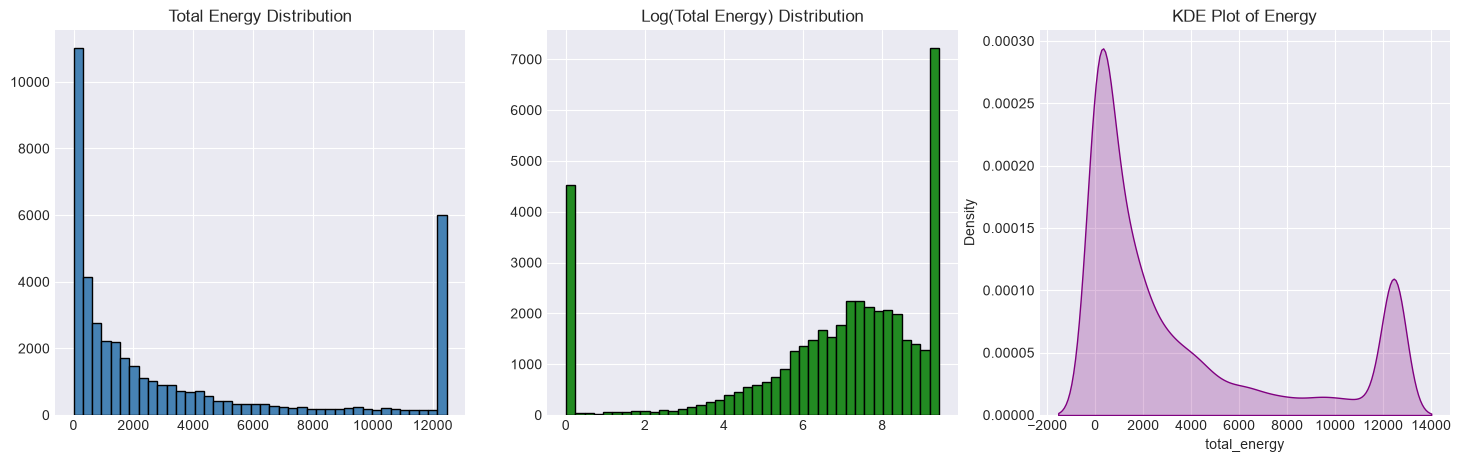

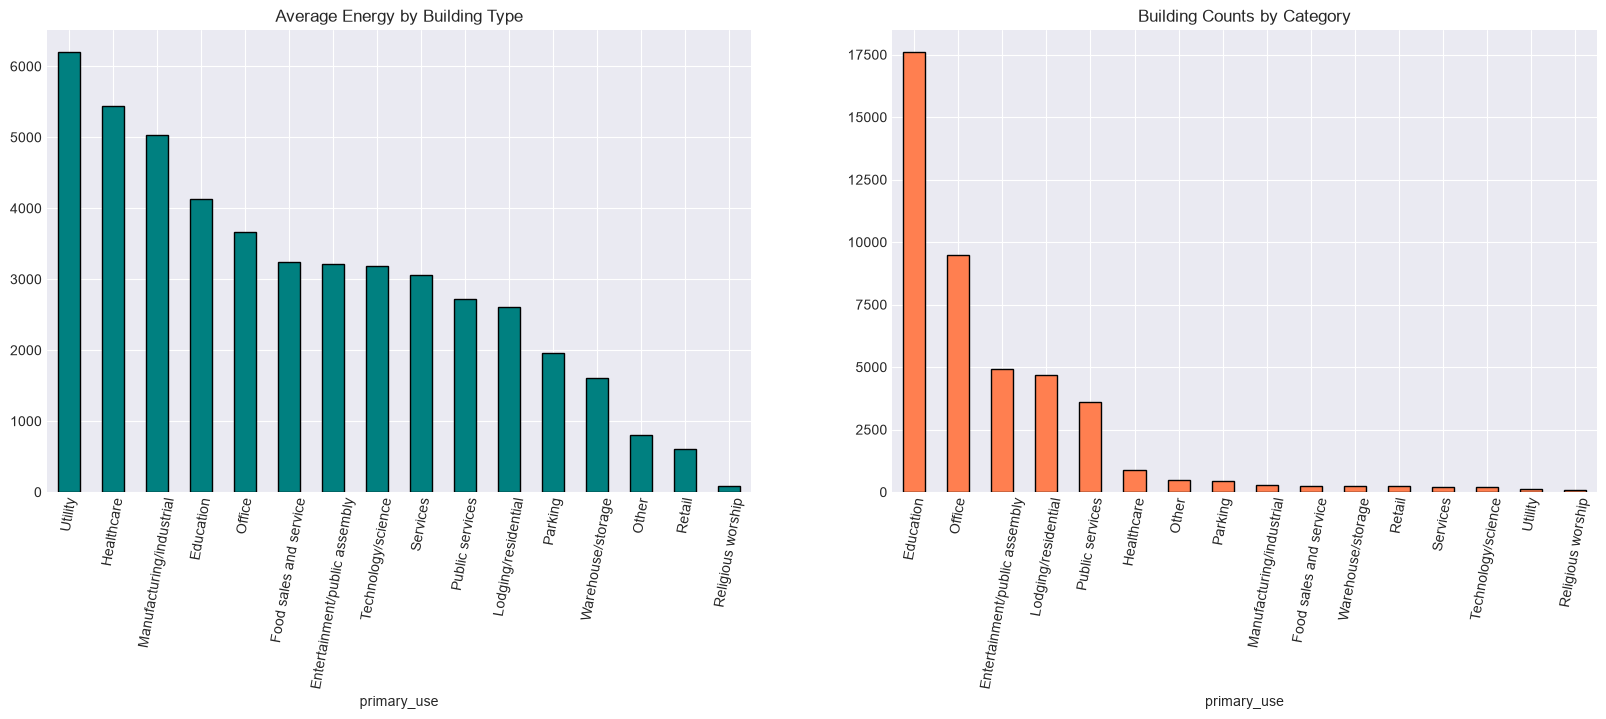

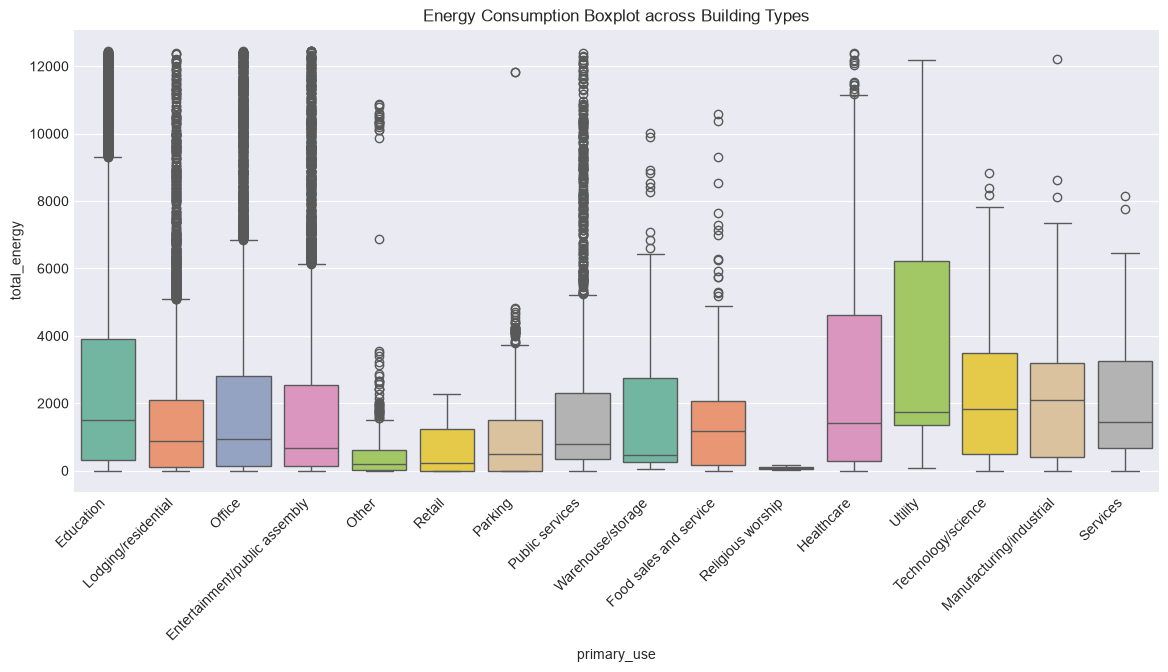

In [16]:

# 1. Energy Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(merged['total_energy'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Total Energy Distribution')

axes[1].hist(np.log1p(merged['total_energy']), bins=40, color='forestgreen', edgecolor='black')
axes[1].set_title('Log(Total Energy) Distribution')

sns.kdeplot(merged['total_energy'], ax=axes[2], color='purple', fill=True)
axes[2].set_title('KDE Plot of Energy')
plt.show()

# 2. Energy by Building Type
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
merged.groupby('primary_use')['total_energy'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Average Energy by Building Type')
axes[0].tick_params(axis='x', rotation=80)

merged['primary_use'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Building Counts by Category')
axes[1].tick_params(axis='x', rotation=80)
plt.show()

# 3. Boxplot by Category (Filtered 95th Percentile)
plt.figure(figsize=(14, 6))
df_filtered = merged[merged['total_energy'] < merged['total_energy'].quantile(0.95)]
sns.boxplot(x='primary_use', y='total_energy', data=df_filtered, palette='Set2')
plt.title('Energy Consumption Boxplot across Building Types')
plt.xticks(rotation=45, ha='right')
plt.show()


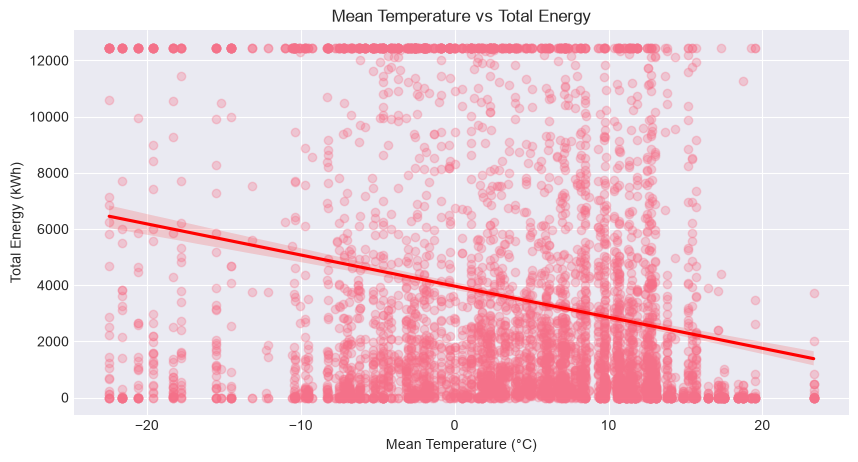

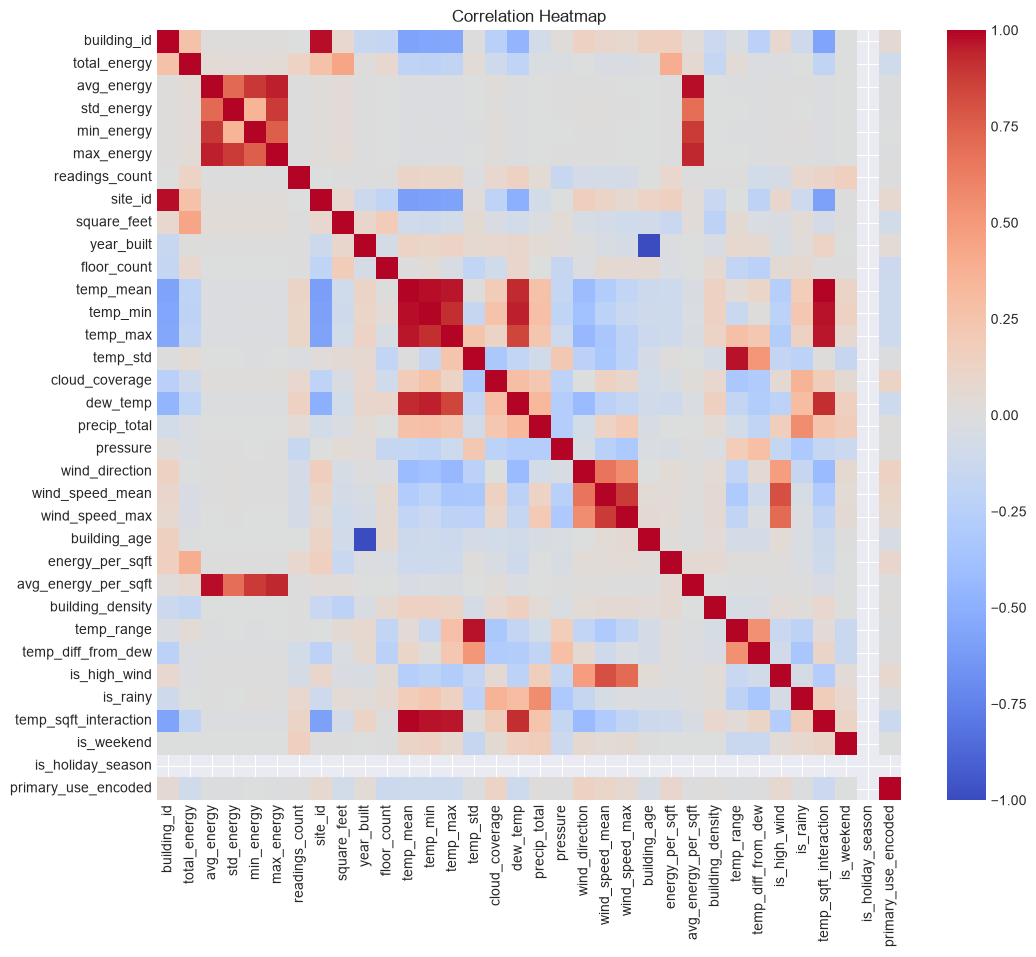

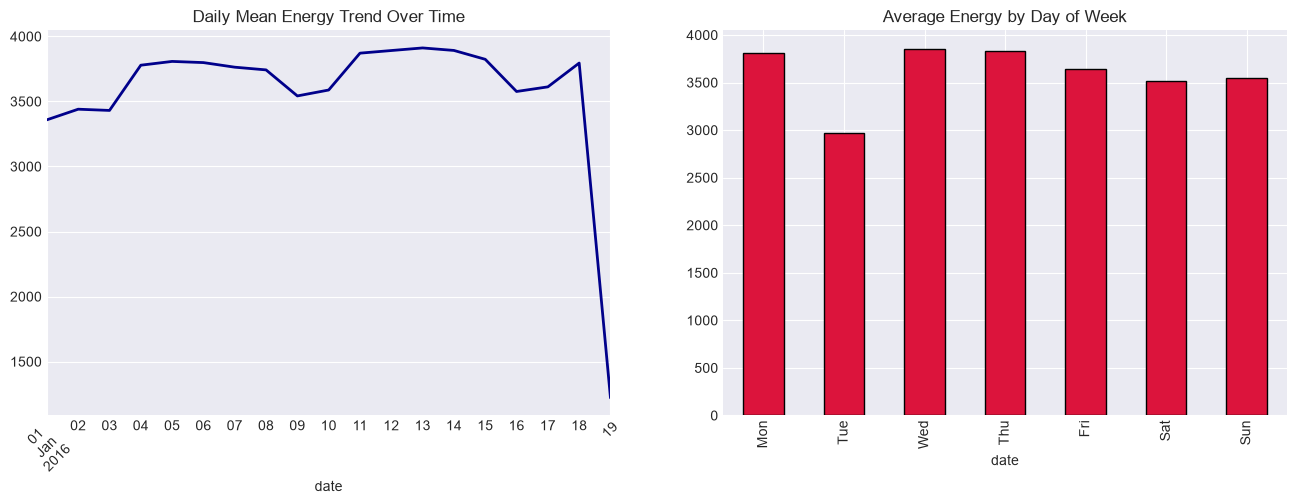

In [17]:

# 4. Temperature vs Energy (Scatter & Trend)
plt.figure(figsize=(10, 5))
sample_df = merged.sample(n=min(5000, len(merged)))
sns.regplot(x='temp_mean', y='total_energy', data=sample_df, line_kws={'color':'red'}, scatter_kws={'alpha': 0.3})
plt.title('Mean Temperature vs Total Energy')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Total Energy (kWh)')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_df = merged.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

# 6. Temporal Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
daily_trend = merged.groupby('date')['total_energy'].mean()
daily_trend.plot(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_title('Daily Mean Energy Trend Over Time')
axes[0].tick_params(axis='x', rotation=45)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_day_mean = merged.groupby(merged['date'].dt.dayofweek)['total_energy'].mean()
daily_day_mean.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='black')
axes[1].set_title('Average Energy by Day of Week')
axes[1].set_xticklabels([day_order[d] for d in daily_day_mean.index])
plt.show()


### 12. Step 11: Split Data & Save Clean Output

In [18]:

target_col = 'total_energy'
exclude_cols = ['total_energy', 'date', 'building_id', 'site_id', 'primary_use',
                'timestamp', 'meter', 'avg_energy', 'std_energy', 'min_energy',
                'max_energy', 'readings_count']

feature_cols = [c for c in merged.columns if c not in exclude_cols]
X = merged[feature_cols]
y = merged[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

# Save data
merged.to_pickle(os.path.join(data_dir, 'merged_clean_comprehensive.pkl'))
print("Comprehensive processed dataset saved successfully!")


X_train: (27990, 30), X_val: (6998, 30), X_test: (8747, 30)
Comprehensive processed dataset saved successfully!
